# Mutation-only Baseline ML

01 でみられた KRAS 変異と MEK 阻害薬感受性の関係が、変異情報のみを用いた予測モデルでも確認できるかを検討する。



In [57]:
from google.colab import drive
drive.mount('/content/drive')

import os
os.chdir('/content/drive/MyDrive/Colab Notebooks/Lung_cancer/nsclc-mutation-drug-response-analysis/notebooks')

print(os.getcwd())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/Colab Notebooks/Lung_cancer/nsclc-mutation-drug-response-analysis/notebooks


In [58]:
import pickle
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import roc_auc_score

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100

# load processed data from 01 notebook
with open('../data/results/processed_data.pkl', 'rb') as f:
    data = pickle.load(f)

mut_matrix= data['mut_matrix']
gdsc_nsclc= data['gdsc_nsclc']
gene_need = data['gene_need']

print('mut_matrix:', mut_matrix.shape)
print('gdsc_nsclc:', gdsc_nsclc.shape)
print('genes:', gene_need)

mut_matrix: (120, 3)
gdsc_nsclc: (26110, 3)
genes: ['EGFR', 'KRAS', 'TP53']


## 1. 説明変数と目的変数の準備

各薬剤について、以下のデータセットを作成する。

- 説明変数: EGFR / KRAS / TP53 の変異有無を表す二値データ
- 目的変数: LN_IC50 を中央値で二分した薬剤感受性ラベル

LN_IC50 が中央値未満の細胞株を高感受性群（1）、中央値以上を低感受性群（0）と定義する。


In [59]:
def make_dataset(drug, gdsc_nsclc, mut_matrix, gene_need, col='LN_IC50'):

    # drug response per cell line
    drug_data = gdsc_nsclc[gdsc_nsclc['DRUG_NAME'] == drug][['ModelID', col]].dropna()

    # merge with mutation features
    df = drug_data.merge(
        mut_matrix.reset_index(),
        on='ModelID',
        how='inner'
    )

    # median split: sensitive (1) if LN_IC50 < median
    median = df[col].median()
    df['label'] = (df[col] < median).astype(int)

    X = df[gene_need].values
    y = df['label'].values

    return X, y, df, median

In [60]:
X_tram, y_tram, df_tram, median_tram = make_dataset(
    'Trametinib', gdsc_nsclc, mut_matrix, gene_need
)

print('Trametinib')
print(f'n samples: {len(y_tram)}')
print(f'median LN_IC50: {median_tram:.3f}')
print(f'sensitive (1): {y_tram.sum()}')
print(f'resistant (0): {(y_tram == 0).sum()}')
print()
print('mutation rate in this dataset:')
for i, gene in enumerate(gene_need):
    print(f'  {gene}: {X_tram[:, i].sum()} / {len(X_tram)}')

Trametinib
n samples: 107
median LN_IC50: -0.124
sensitive (1): 53
resistant (0): 54

mutation rate in this dataset:
  EGFR: 20 / 107
  KRAS: 30 / 107
  TP53: 87 / 107


In [61]:
X_pd, y_pd, df_pd, median_pd = make_dataset(
    'PD0325901', gdsc_nsclc, mut_matrix, gene_need
)

print('PD0325901')
print(f' n samples: {len(y_pd)}')
print(f' median LN_IC50: {median_pd:.3f}')
print(f' sensitive (1): {y_pd.sum()}')
print(f' resistant (0): {(y_pd == 0).sum()}')
print()
print('mutation rate in this dataset:')
for i, gene in enumerate(gene_need):
    print(f'  {gene}: {X_pd[:, i].sum()} / {len(X_pd)}')

PD0325901
 n samples: 107
 median LN_IC50: 1.153
 sensitive (1): 53
 resistant (0): 54

mutation rate in this dataset:
  EGFR: 20 / 107
  KRAS: 30 / 107
  TP53: 87 / 107


## 2. モデルの学習と評価

2 つのモデルを 5-fold cross-validation で評価する。

- Logistic Regression: 線形モデルであり、係数の解釈がしやすい
- Random Forest: 非線形な関係や特徴量間の相互作用も扱える

評価指標には AUC を用いる。サンプル数が限られるため、単純な訓練データ・テストデータの分割では結果が不安定になりやすい。そこで、交差検証により平均 AUC と標準偏差を確認する。

In [62]:
def evaluate_model(X, y, model, n_splits=5, random_state=42):

    cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=random_state)
    scores = cross_val_score(model, X, y, cv=cv, scoring='roc_auc')
    return scores


def run_models(X, y, drug_name):

    print(f'=== {drug_name} ===')
    print(f'n samples: {len(y)} (sensitive: {y.sum()}, resistant: {(y==0).sum()})')
    print()

    # Logistic Regression
    logreg = LogisticRegression(max_iter=1000, random_state=42)
    auc_lr = evaluate_model(X, y, logreg)

    # Random Forest
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    auc_rf = evaluate_model(X, y, rf)

    print(f'LogReg AUC: {auc_lr.mean():.3f} (+/- {auc_lr.std():.3f})')
    print(f'per fold: {np.round(auc_lr, 3)}')
    print(f'RF AUC:     {auc_rf.mean():.3f} (+/- {auc_rf.std():.3f})')
    print(f'per fold: {np.round(auc_rf, 3)}')

    return {
        'drug': drug_name,
        'logreg_auc_mean': auc_lr.mean(),
        'logreg_auc_std': auc_lr.std(),
        'logreg_aucs': auc_lr,
        'rf_auc_mean': auc_rf.mean(),
        'rf_auc_std': auc_rf.std(),
        'rf_aucs': auc_rf,
    }

In [63]:
result_tram = run_models(X_tram, y_tram, 'Trametinib')
print()
result_pd= run_models(X_pd, y_pd, 'PD0325901')

=== Trametinib ===
n samples: 107 (sensitive: 53, resistant: 54)

LogReg AUC: 0.647 (+/- 0.121)
per fold: [0.579 0.579 0.845 0.509 0.723]
RF AUC:     0.590 (+/- 0.065)
per fold: [0.579 0.587 0.627 0.482 0.677]

=== PD0325901 ===
n samples: 107 (sensitive: 53, resistant: 54)

LogReg AUC: 0.584 (+/- 0.083)
per fold: [0.483 0.612 0.568 0.532 0.727]
RF AUC:     0.594 (+/- 0.041)
per fold: [0.583 0.579 0.586 0.55  0.673]


## 3. 各変異の寄与の確認

どの遺伝子変異が予測に関与しているかを確認する。

- Logistic Regression: 係数の符号と大きさ
- Random Forest: 変数重要度

特に、01 の探索解析で注目した KRAS 変異が、予測モデルでも一定の寄与を示すかを確認する。

In [64]:
def feature_contribution(X, y, drug_name, gene_need):

    # logistic regression coefficients
    logreg = LogisticRegression(max_iter=1000, random_state=42)
    logreg.fit(X, y)
    coefs = logreg.coef_[0]

    # random forest feature importance
    rf = RandomForestClassifier(n_estimators=200, random_state=42)
    rf.fit(X, y)
    importances = rf.feature_importances_

    df = pd.DataFrame({
        'gene': gene_need,
        'logreg_coef': coefs,
        'rf_importance': importances,
    })

    print(f'=== {drug_name} ===')
    print(df.to_string(index=False))
    print()

    return df


fc_tram = feature_contribution(X_tram, y_tram, 'Trametinib', gene_need)
fc_pd = feature_contribution(X_pd, y_pd, 'PD0325901', gene_need)

=== Trametinib ===
gene  logreg_coef  rf_importance
EGFR    -0.158196       0.154029
KRAS     0.698202       0.402630
TP53    -0.902022       0.443341

=== PD0325901 ===
gene  logreg_coef  rf_importance
EGFR     0.008996       0.226243
KRAS     0.743320       0.510198
TP53    -0.473793       0.263559



## 4. AUC の比較

In [65]:
results_summary = pd.DataFrame([
    {'drug': 'Trametinib', 'model': 'LogReg', 'auc': result_tram['logreg_auc_mean'], 'std': result_tram['logreg_auc_std']},
    {'drug': 'Trametinib', 'model': 'RF','auc': result_tram['rf_auc_mean'],'std': result_tram['rf_auc_std']},
    {'drug': 'PD0325901',  'model': 'LogReg', 'auc': result_pd['logreg_auc_mean'],'std': result_pd['logreg_auc_std']},
    {'drug': 'PD0325901',  'model': 'RF', 'auc': result_pd['rf_auc_mean'],'std': result_pd['rf_auc_std']},
])

print(results_summary.to_string(index=False))

      drug  model      auc      std
Trametinib LogReg 0.646860 0.121259
Trametinib     RF 0.590331 0.064577
 PD0325901 LogReg 0.584463 0.082904
 PD0325901     RF 0.594050 0.041379


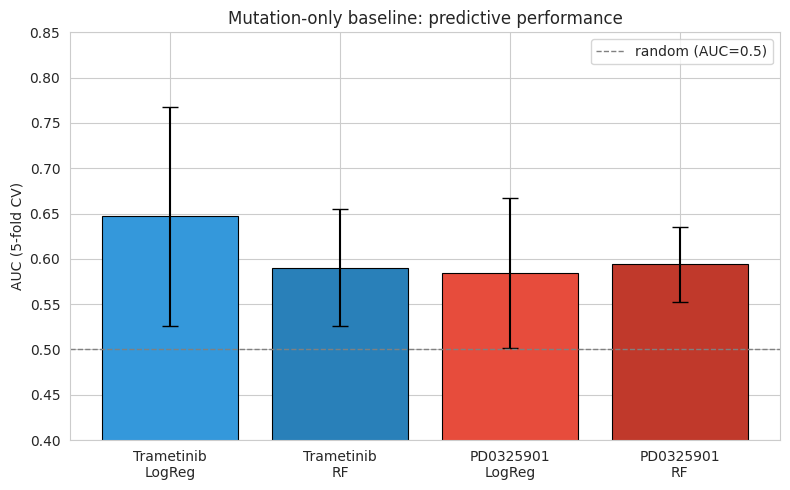

In [66]:
fig, ax = plt.subplots(figsize=(8, 5))

x_labels = [f"{r['drug']}\n{r['model']}" for _, r in results_summary.iterrows()]
positions = np.arange(len(results_summary))
colors = ['#3498db', '#2980b9', '#e74c3c', '#c0392b']

ax.bar(
    positions,
    results_summary['auc'],
    yerr=results_summary['std'],
    color=colors,
    capsize=6,
    edgecolor='black',
    linewidth=0.8,
)

ax.axhline(y=0.5, color='gray', linestyle='--', linewidth=1, label='random (AUC=0.5)')
ax.set_xticks(positions)
ax.set_xticklabels(x_labels)
ax.set_ylabel('AUC (5-fold CV)')
ax.set_ylim(0.4, 0.85)
ax.set_title('Mutation-only baseline: predictive performance')
ax.legend(loc='upper right')

plt.tight_layout()
plt.show()

## 5. まとめ

- 両薬剤で KRAS 変異の係数が正となり、01 でみられた感受性傾向と方向が一致した
- 平均 AUC は 0.58〜0.65 程度であり、無作為予測をやや上回ったものの、予測性能は限定的であった
- Logistic Regression と Random Forest の性能差は大きくなく、3 遺伝子の変異情報だけでは予測に限界があると考えられる
- 今後は、発現量やコピー数変化を加えた解析へ拡張する余地がある

In [67]:
# save ML results
ml_results = {
    'result_tram': result_tram,
    'result_pd': result_pd,
    'fc_tram': fc_tram,
    'fc_pd': fc_pd,
    'results_summary': results_summary,
}

os.makedirs('../data/results', exist_ok=True)

with open('../data/results/ml_results.pkl', 'wb') as f:
    pickle.dump(ml_results, f)

print('saved: ../data/results/ml_results.pkl')

saved: ../data/results/ml_results.pkl
